<a href="https://colab.research.google.com/github/vinaygm04/ML-LAB/blob/main/pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [ ]:
# =========================
# 1. Import Libraries
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score


# =========================
# 2. Load Dataset
# =========================
df = pd.read_csv("/content/heart.csv")
print("Dataset Shape:", df.shape)
print(df.head())



Dataset Shape: (918, 12)
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  


In [ ]:
# =========================
# 3. Preprocessing
# =========================

# Check for categorical columns
for col in df.columns:
    if df[col].dtype == 'object':
        print("Encoding column:", col)
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])

# Separate features and target
X = df.drop('HeartDisease', axis=1)   # assuming target column name is 'HeartDisease'
y = df['HeartDisease']


# =========================
# 4. Scaling
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# =========================
# 5. Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


# =========================
# 6. Models BEFORE PCA
# =========================
print("\n--- BEFORE PCA ---")

models = {
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier()
}

before_pca_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    before_pca_results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")



Encoding column: Sex
Encoding column: ChestPainType
Encoding column: RestingECG
Encoding column: ExerciseAngina
Encoding column: ST_Slope

--- BEFORE PCA ---
Logistic Regression Accuracy: 0.8478
SVM Accuracy: 0.8641
Random Forest Accuracy: 0.8967



Logistic Regression Confusion Matrix (Before PCA):


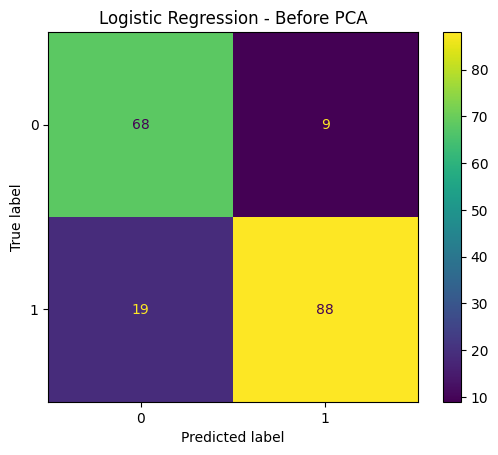


SVM Confusion Matrix (Before PCA):


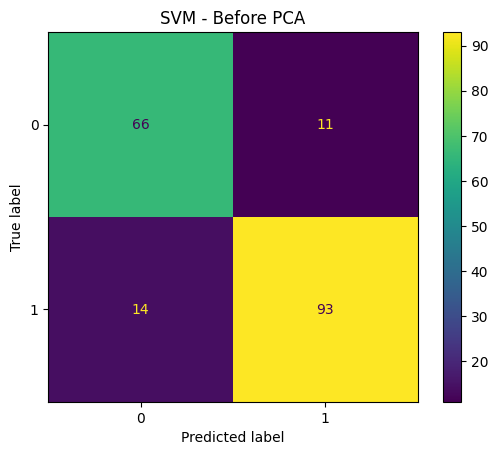


Random Forest Confusion Matrix (Before PCA):


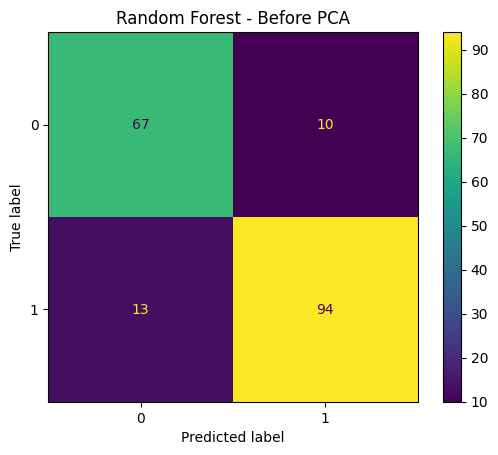

In [ ]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name} Confusion Matrix (Before PCA):")

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{name} - Before PCA")
    plt.show()

In [ ]:
# =========================
# 7. Apply PCA
# =========================
# Reduce dimensions (choose components, e.g., 5 or variance 95%)
pca = PCA(n_components=0.95)  # keep 95% variance
X_pca = pca.fit_transform(X_scaled)

print("\nReduced Dimensions:", X_pca.shape)


# Split again after PCA
X_train_pca, X_test_pca, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)


# =========================
# 8. Models AFTER PCA
# =========================
print("\n--- AFTER PCA ---")

after_pca_results = {}

for name, model in models.items():
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)
    after_pca_results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")


# =========================
# 9. Comparison
# =========================
print("\n--- COMPARISON ---")
for model in models.keys():
    print(f"{model}: Before PCA = {before_pca_results[model]:.4f}, After PCA = {after_pca_results[model]:.4f}")


Reduced Dimensions: (918, 10)

--- AFTER PCA ---
Logistic Regression Accuracy: 0.8424
SVM Accuracy: 0.8750
Random Forest Accuracy: 0.8533

--- COMPARISON ---
Logistic Regression: Before PCA = 0.8478, After PCA = 0.8424
SVM: Before PCA = 0.8641, After PCA = 0.8750
Random Forest: Before PCA = 0.8967, After PCA = 0.8533



Logistic Regression Confusion Matrix (After PCA):


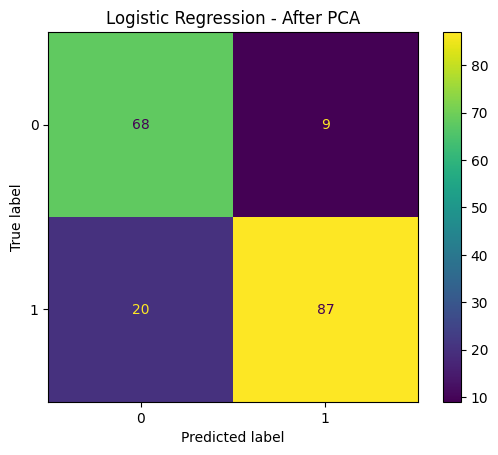


SVM Confusion Matrix (After PCA):


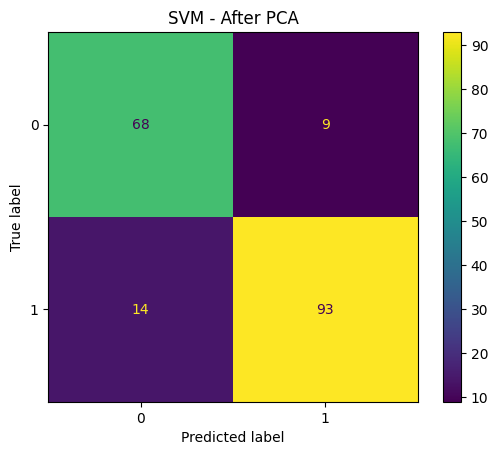


Random Forest Confusion Matrix (After PCA):


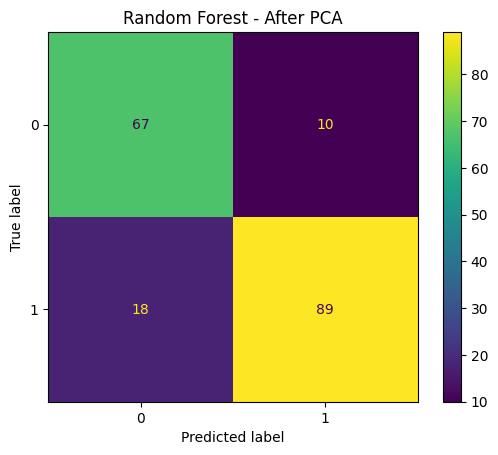

In [ ]:
for name, model in models.items():
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)

    print(f"\n{name} Confusion Matrix (After PCA):")

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{name} - After PCA")
    plt.show()

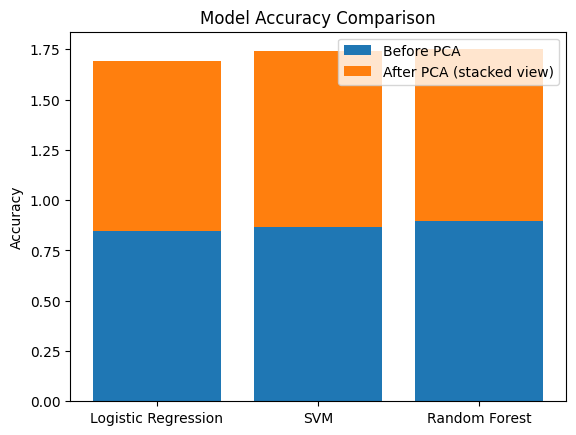

In [ ]:
import matplotlib.pyplot as plt

model_names = list(before_pca_results.keys())
before_vals = list(before_pca_results.values())
after_vals = list(after_pca_results.values())

x = range(len(model_names))

plt.figure()
plt.bar(x, before_vals, label='Before PCA')
plt.bar(x, after_vals, bottom=before_vals, label='After PCA (stacked view)')
plt.xticks(x, model_names)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.legend()
plt.show()

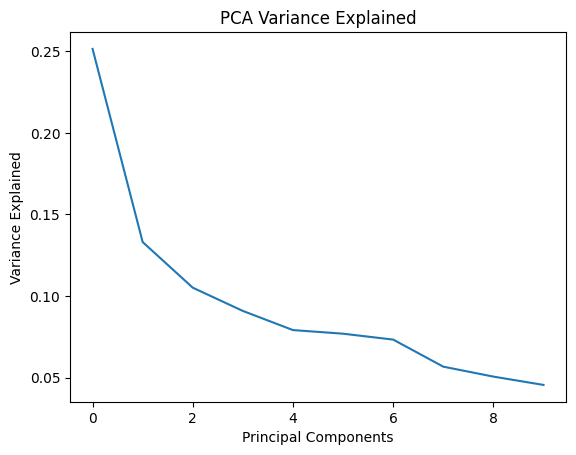

In [ ]:
plt.figure()
plt.plot(pca.explained_variance_ratio_)
plt.xlabel("Principal Components")
plt.ylabel("Variance Explained")
plt.title("PCA Variance Explained")
plt.show()